# Dark Pattern Detection Pipeline: PaddleOCR + DistilRoBERTa

This notebook implements an end-to-end pipeline:

1. **PaddleOCR** — extracts all visible text from an input image (e.g. a screenshot of a webpage).
2. **DistilRoBERTa** — classifies each extracted text snippet as a **Dark Pattern** (1) or **Not a Dark Pattern** (0).

This is designed to work directly with screenshots from the browser extension pipeline.

In [ ]:
# Install dependencies if not already installed
# !pip install paddlepaddle paddleocr transformers torch

In [1]:
import torch
import re
import os
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from paddleocr import PaddleOCR
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── Device ────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ── Load PaddleOCR ────────────────────────────────────────────────────────────
# use_angle_cls=True handles rotated text; lang='en' for English
ocr = PaddleOCR(use_angle_cls=True, lang='en', show_log=False)
print("PaddleOCR loaded.")

# ── Load DistilRoBERTa Model ──────────────────────────────────────────────────
model_path = "./distilroberta_darkpattern_detection"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
model.eval()
print("DistilRoBERTa model loaded.")

Using device: cuda
PaddleOCR loaded.
DistilRoBERTa model loaded.


In [2]:
def clean_text(text):
    """Remove URLs and normalize whitespace."""
    text = re.sub(r'http\S+', '', str(text))
    return " ".join(text.split())

def classify_text(texts):
    """
    Run DistilRoBERTa inference on a list of strings.
    Returns a list of (text, label, confidence) tuples.
    Labels: 0 = Not Dark Pattern, 1 = Dark Pattern
    """
    results = []
    if not texts:
        return results
    with torch.no_grad():
        for text in texts:
            cleaned = clean_text(text)
            if not cleaned:
                continue
            inputs = tokenizer(
                cleaned,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=256
            ).to(device)
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1).squeeze()
            label = torch.argmax(probs).item()
            confidence = probs[label].item()
            results.append((cleaned, label, confidence))
    return results

def run_pipeline(image_path):
    """
    Full pipeline:
      1. Run PaddleOCR to extract (text, bounding_box) pairs from the image.
      2. Run DistilRoBERTa to classify each text.
      3. Print a report and annotate the image.

    Args:
        image_path (str): Path to the input image (jpg/png).

    Returns:
        annotated_image (PIL.Image): Image with dark patterns highlighted.
        report (list of dict): Detailed per-text results.
    """
    # ── Step 1: OCR ─────────────────────────────────────────────────────────
    print(f"\nRunning OCR on: {image_path}")
    ocr_result = ocr.ocr(image_path, cls=True)

    # PaddleOCR format: [[ [[x1,y1],[x2,y2],[x3,y3],[x4,y4]], (text, score) ], ... ]
    extracted = []
    if ocr_result and ocr_result[0]:
        for line in ocr_result[0]:
            box, (text, ocr_conf) = line[0], line[1]
            extracted.append({"text": text, "box": box, "ocr_conf": ocr_conf})

    print(f"OCR extracted {len(extracted)} text regions.")

    # ── Step 2: Classify ─────────────────────────────────────────────────────
    texts = [e["text"] for e in extracted]
    classifications = classify_text(texts)

    # Merge back
    report = []
    for i, (text, label, conf) in enumerate(classifications):
        report.append({
            "text": text,
            "label": label,
            "label_name": "Dark Pattern" if label == 1 else "Not Dark Pattern",
            "confidence": round(conf, 4),
            "box": extracted[i]["box"] if i < len(extracted) else None
        })

    # ── Step 3: Annotate ─────────────────────────────────────────────────────
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for item in report:
        if item["box"] is None:
            continue
        box = item["box"]
        # Flatten box to flat polygon list for PIL
        pts = [(int(pt[0]), int(pt[1])) for pt in box]
        color = "red" if item["label"] == 1 else "green"
        draw.polygon(pts, outline=color)
        draw.text(pts[0], item["label_name"][:4], fill=color)  # short label

    # ── Step 4: Report ───────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"{'TEXT':<45} {'LABEL':<16} {'CONF':>6}")
    print("=" * 60)
    for item in report:
        print(f"{item['text'][:44]:<45} {item['label_name']:<16} {item['confidence']:>6.2%}")
    print("=" * 60)
    dark_count = sum(1 for r in report if r["label"] == 1)
    print(f"\nTotal regions: {len(report)} | Dark patterns found: {dark_count}")

    return img, report

## Run the Pipeline on an Image


Running OCR on: D:\SEM6\DL\DARK\ContextRico-DP\Web\(269)pages.daraz.lk_115d.jpg
OCR extracted 47 text regions.

TEXT                                          LABEL              CONF
UP TO 4O MONTH                                Dark Pattern     99.99%
BANK OF CEYLON                                Not Dark Pattern 99.93%
HNB                                           Not Dark Pattern 99.94%
PeoPLE's                                      Not Dark Pattern 99.94%
NDB bank                                      Not Dark Pattern 99.92%
SampathCards                                  Not Dark Pattern 99.96%
Standard                                      Not Dark Pattern 99.94%
(I> COMMERCAL BANK                            Not Dark Pattern 99.69%
BUNION BANK                                   Not Dark Pattern 99.89%
Chartered                                     Not Dark Pattern 99.93%
INSTALLMENT PLAN AT O%                        Dark Pattern     86.94%
The Bank of the Peoplo                        N

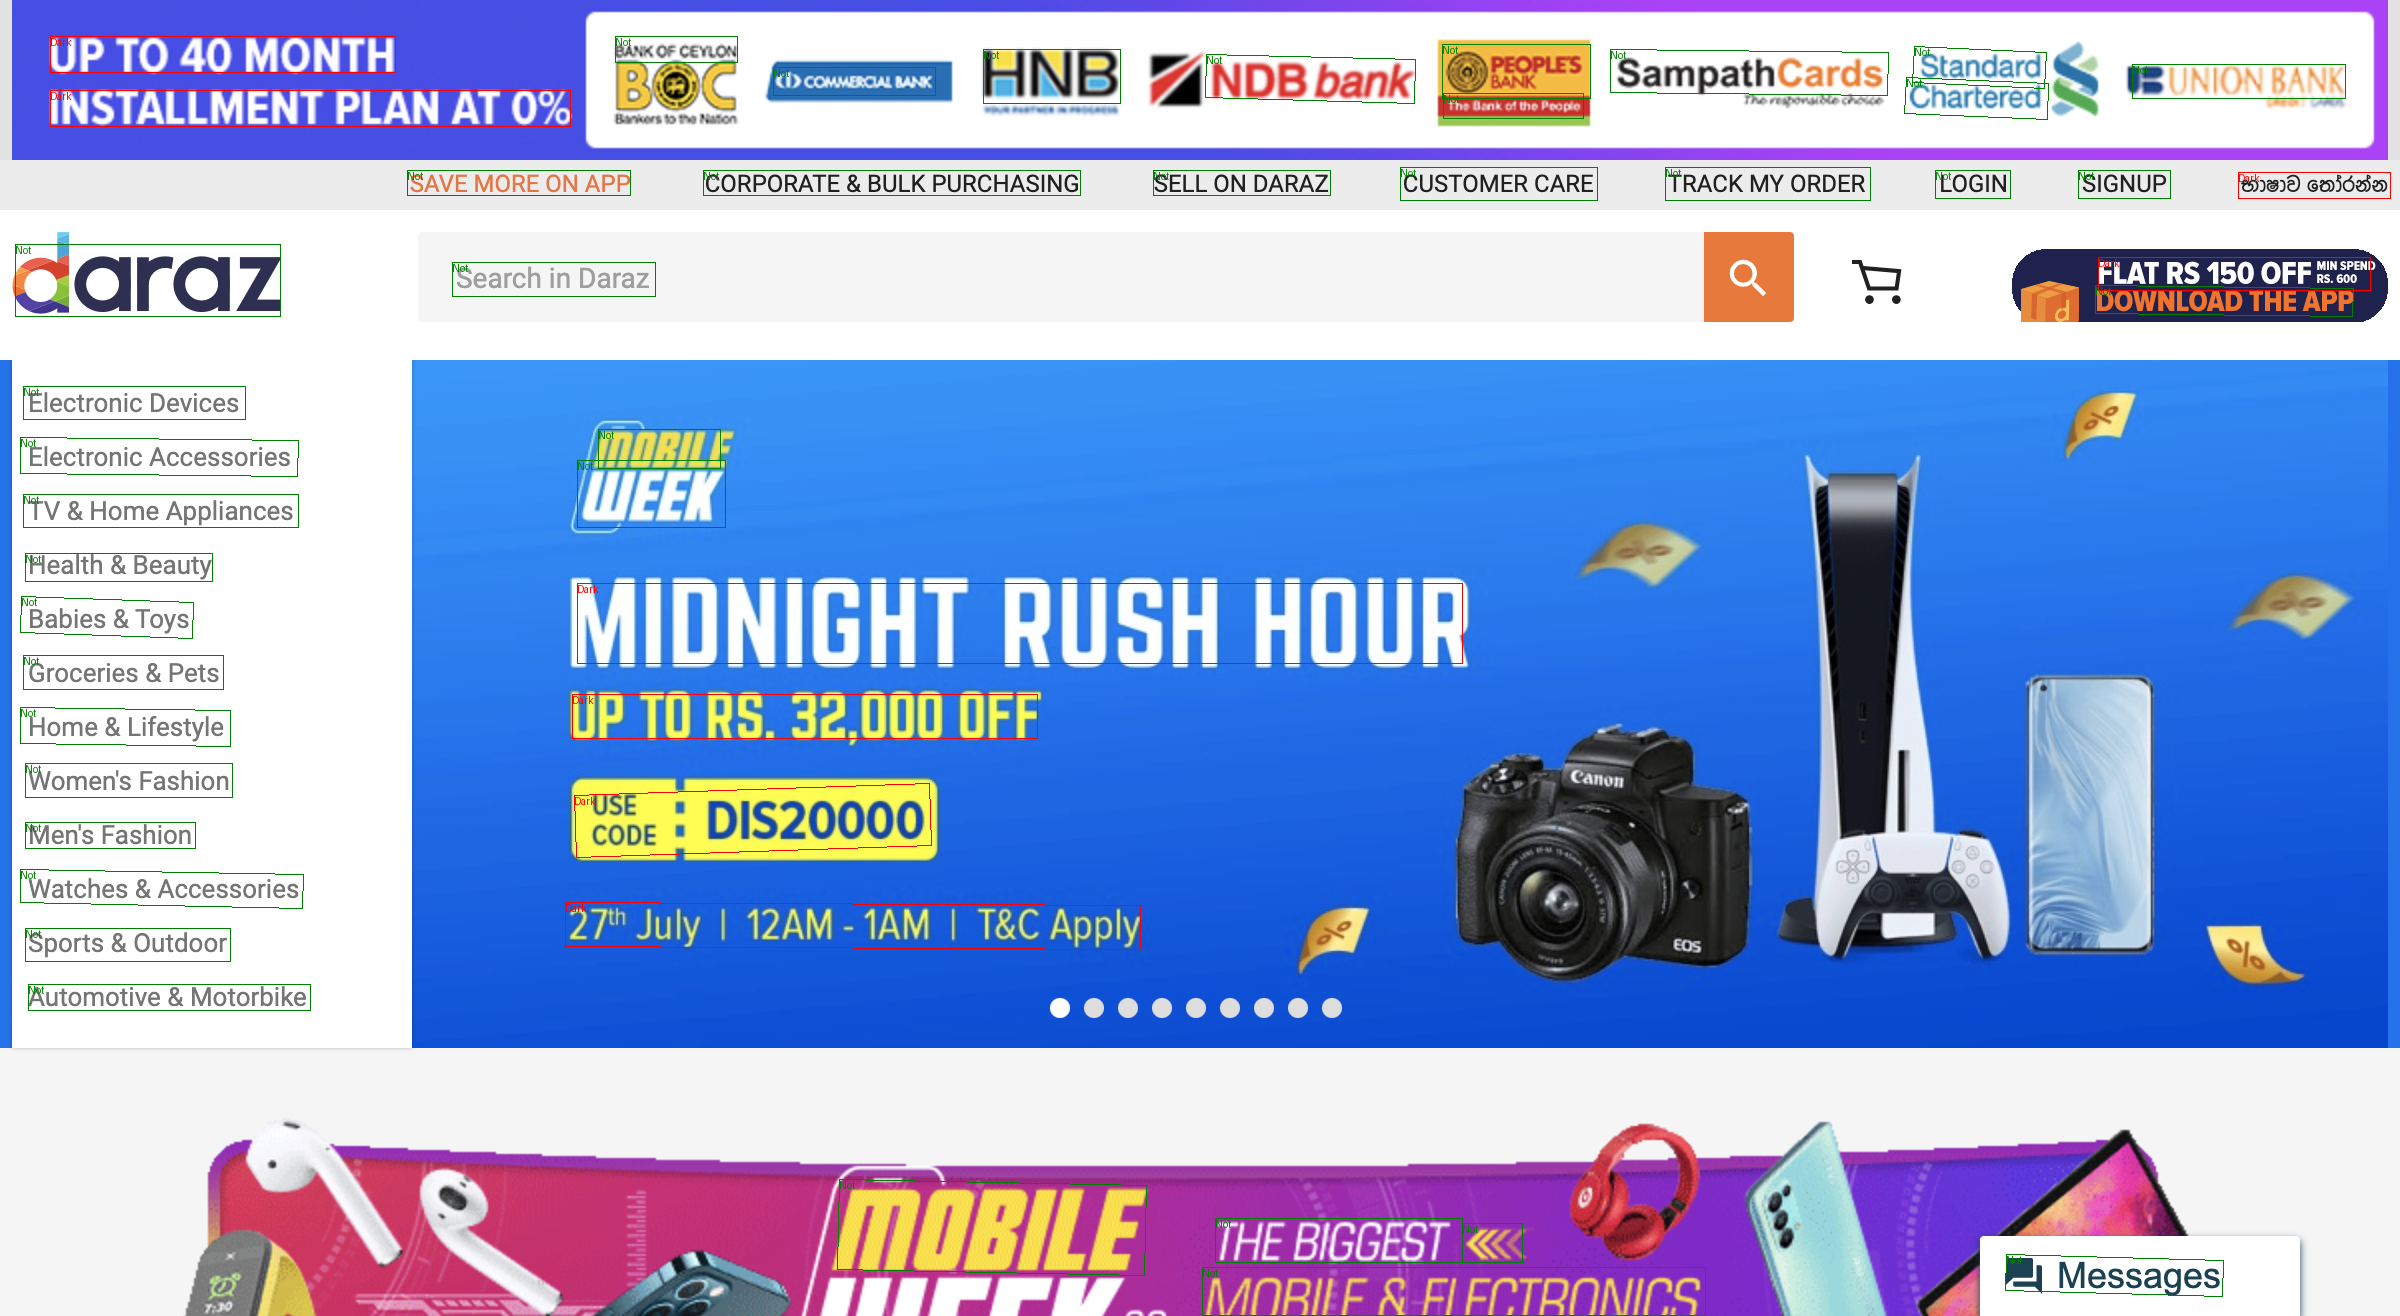


Annotated image saved to: annotated_(269)pages.daraz.lk_115d.jpg


In [5]:
# ── Point this to your screenshot ────────────────────────────────────────────
IMAGE_PATH = "D:\SEM6\DL\DARK\ContextRico-DP\Web\(269)pages.daraz.lk_115d.jpg"   # Replace with your image path

# Make sure the file exists
if not os.path.exists(IMAGE_PATH):
    print(f"ERROR: '{IMAGE_PATH}' not found. Please update IMAGE_PATH.")
else:
    annotated_img, report = run_pipeline(IMAGE_PATH)

    # Show the annotated image inline
    display(annotated_img)

    # Optionally save the annotated output
    output_path = "annotated_" + os.path.basename(IMAGE_PATH)
    annotated_img.save(output_path)
    print(f"\nAnnotated image saved to: {output_path}")

## Quick Text-Only Test (No Image Required)

In [4]:
# ── Quick test without an image ─────────────────────────────────────────────
# Useful for sanity-checking the DistilRoBERTa model independently.

test_texts = [
    "Only 2 items left in stock! Order NOW before it's gone!",
    "Pillowcases & Shams",
    "1,234 people are viewing this item right now",
    "Satisfaction guaranteed or your money back",
    "Add insurance for only $1.99/month — pre-selected for you",
    "Write a review",
    "FREE SHIPPING — today only!",
    "Blue denim jacket, regular fit",
]

results = classify_text(test_texts)

print(f"{'TEXT':<50} {'LABEL':<18} {'CONF':>6}")
print("-" * 76)
for text, label, conf in results:
    label_name = "Dark Pattern" if label == 1 else "Not Dark Pattern"
    print(f"{text[:49]:<50} {label_name:<18} {conf:>6.2%}")

TEXT                                               LABEL                CONF
----------------------------------------------------------------------------
Only 2 items left in stock! Order NOW before it's  Dark Pattern       99.99%
Pillowcases & Shams                                Not Dark Pattern   99.94%
1,234 people are viewing this item right now       Dark Pattern       99.99%
Satisfaction guaranteed or your money back         Not Dark Pattern   94.30%
Add insurance for only $1.99/month — pre-selected  Dark Pattern       99.98%
Write a review                                     Not Dark Pattern   99.89%
FREE SHIPPING — today only!                        Dark Pattern       99.97%
Blue denim jacket, regular fit                     Not Dark Pattern   99.90%
